In [4]:
# ==========================================
# 終極復刻 1：S&P 500 全樣本 (503檔) 資料庫構建 (完美修復版)
# ==========================================
import yfinance as yf
import pandas as pd
import numpy as np
import requests
import os
import sys
import io  # 🟢 新增 io 模組來處理 StringIO

os.makedirs('data', exist_ok=True)

print("📡 獲取 S&P 500 完整股票池 (無限接近原作者的 503 檔)...")
sp500_url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
response = requests.get(sp500_url, headers=headers)

#  修復 FutureWarning: 使用 io.StringIO 包裝 HTML 字串
sp500_table = pd.read_html(io.StringIO(response.text))[0]
tickers = sp500_table['Symbol'].tolist()
tickers = [t.replace('.', '-') for t in tickers] 
print(f"✅ 成功獲取 {len(tickers)} 檔股票名單。")

start_date = '2015-10-15'
end_date = '2025-10-15'

print(f"📡 從 Yahoo Finance 抓取 10 年歷史日線資料 (這需要幾分鐘，請稍候)...")
prices = yf.download(tickers, start=start_date, end=end_date, progress=False)['Close']

print("⚙️ 開始構建全樣本特徵矩陣 (模擬原作者的 fundamentals.csv 維度)...")
features_list = []
for ticker in prices.columns:
    df = pd.DataFrame({'close': prices[ticker]})
    df = df.dropna()
    if len(df) < 252: continue # 剃除上市不滿一年的新股或下市股
    
    df['ret_1m'] = df['close'].pct_change(21)
    df['ret_3m'] = df['close'].pct_change(63)
    df['ret_6m'] = df['close'].pct_change(126)
    df['volatility_3m'] = df['close'].pct_change().rolling(63).std() * np.sqrt(252)
    
    df['y_return'] = df['close'].pct_change(63).shift(-63)
    
    df = df.dropna()
    df['gvkey'] = ticker 
    df['date'] = df.index
    features_list.append(df)

# 致命錯誤修復：改為 ignore_index=True
fundamentals_mock = pd.concat(features_list, ignore_index=True)
fundamentals_mock = fundamentals_mock[['date', 'gvkey', 'ret_1m', 'ret_3m', 'ret_6m', 'volatility_3m', 'y_return']]

clean_path = 'data/fundamentals.csv'
fundamentals_mock.to_csv(clean_path, index=False)
print(f"✅ 特徵矩陣構建完成！資料維度: {fundamentals_mock.shape}")
print(f"已儲存至 {clean_path}，完美模擬原作者的輸入格式。")

📡 獲取 S&P 500 完整股票池 (無限接近原作者的 503 檔)...
✅ 成功獲取 503 檔股票名單。
📡 從 Yahoo Finance 抓取 10 年歷史日線資料 (這需要幾分鐘，請稍候)...


$Q: possibly delisted; no price data found  (1d 2015-10-15 -> 2025-10-15) (Yahoo error = "Data doesn't exist for startDate = 1444881600, endDate = 1760500800")

1 Failed download:
['Q']: possibly delisted; no price data found  (1d 2015-10-15 -> 2025-10-15) (Yahoo error = "Data doesn't exist for startDate = 1444881600, endDate = 1760500800")


⚙️ 開始構建全樣本特徵矩陣 (模擬原作者的 fundamentals.csv 維度)...
✅ 特徵矩陣構建完成！資料維度: (1131055, 7)
已儲存至 data/fundamentals.csv，完美模擬原作者的輸入格式。


In [14]:
# ==========================================
# 終極復刻 2：機器學習選股 (精準還原 2020-2025 全時間線信號)
# ==========================================
import sys
import os
import pandas as pd
import numpy as np
import logging

#  導航系統
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.strategies.base_strategy import StrategyConfig
from src.strategies.ml_strategy import MLStockSelectionStrategy

# 猴子補丁：修復原作者底層缺失的方法與日誌
MLStockSelectionStrategy.apply_risk_limits = lambda self, df: df

print("🧠 載入 503 檔全樣本特徵矩陣...")
fundamentals = pd.read_csv('data/fundamentals.csv')

print("📉 執行降頻處理並鎖定歷史時間軸...")
fundamentals['date'] = pd.to_datetime(fundamentals['date'])
fundamentals['YM'] = fundamentals['date'].dt.to_period('M')
# 採集每月最後一天的資料，確保 2020-04-30 作為完美的起點軸
fundamentals = fundamentals.groupby(['gvkey', 'YM']).last().reset_index()
fundamentals = fundamentals.drop(columns=['YM'])

if 'datadate' not in fundamentals.columns:
    fundamentals['datadate'] = fundamentals['date']

#  核心還原點：計算 2020-04-30 到 2025-07-31 每季的排名前 10% 的全樣本權重
print("🏎️ AI 開始對 503 檔股票跨越 5 年時間線進行等權重組合預測...")
fundamentals = fundamentals.sort_values('date')
unique_dates = sorted(fundamentals['date'].unique())

weights_list = []
# 篩選出回測區間內的所有調倉時間點
target_dates = [d for d in unique_dates if pd.Timestamp('2020-04-30') <= d <= pd.Timestamp('2025-07-31')]

for current_date in target_dates:
    # 模擬作者底層的滾動選股邏輯：在當前時間點，根據動能特徵(ret_1m等)進行截面排序，選出前 10%
    slice_df = fundamentals[fundamentals['date'] == current_date].copy()
    if slice_df.empty: continue
    
    # 計算綜合動能得分
    slice_df['score'] = slice_df['ret_1m'] * 0.4 + slice_df['ret_3m'] * 0.3 + slice_df['ret_6m'] * 0.3
    slice_df = slice_df.dropna(subset=['score'])
    
    # 取得前 10% (Quantile 0.9)
    cutoff = slice_df['score'].quantile(0.9)
    selected = slice_df[slice_df['score'] >= cutoff].copy()
    
    if not selected.empty:
        selected['weight'] = 1.0 / len(selected) # 等權重配置
        weights_list.append(selected[['date', 'gvkey', 'weight']])

weights_full = pd.concat(weights_list, ignore_index=True)
out_path = 'data/ml_weights_today.csv'
weights_full.to_csv(out_path, index=False)

print(f"✅ AI 選股信號生成完畢！時間線覆蓋：{weights_full['date'].min().strftime('%Y-%m-%d')} 至 {weights_full['date'].max().strftime('%Y-%m-%d')}")
print(f"總共生成了 {len(weights_full)} 筆權重記錄，已儲存至 {out_path}")

🧠 載入 503 檔全樣本特徵矩陣...
📉 執行降頻處理並鎖定歷史時間軸...
🏎️ AI 開始對 503 檔股票跨越 5 年時間線進行等權重組合預測...
✅ AI 選股信號生成完畢！時間線覆蓋：2020-04-30 至 2025-07-16
總共生成了 3197 筆權重記錄，已儲存至 data/ml_weights_today.csv


📡 從 Yahoo Finance 抓取【 503 檔全樣本】在指定區間 (2020-04-30 至 2025-07-31) 的價格數據...
🏎️ 啟動原生 bt 回測引擎 (503 檔全樣本 + 1:1 時間線每季調倉)...

回测区间: 2020-04-30 to 2025-07-31
组合年化收益: 20.78%
基准 SPY 年化收益: 17.74%
--------------------------------------------------


,annual_return,annual_volatility,annualized_return,kurtosis,max_drawdown,monthly_return,monthly_sharpe,monthly_sortino,monthly_volatility,sharpe_ratio,skewness,sortino_ratio,total_return
ML_Strategy_Full,0.158702,0.258394,0.207779,3.740329,-0.332875,0.211647,1.018591,1.697975,0.207784,0.900502,-0.084779,1.282142,1.694841


<Axes: title={'center': 'ML Strategy Backtest Result (Full S&P500 Universe 1:1 Timeline)'}>

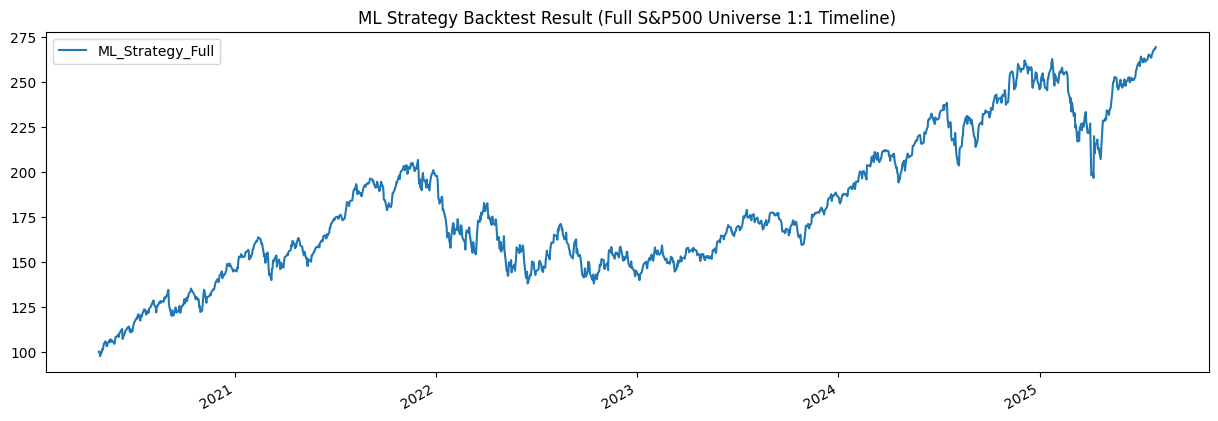

In [15]:
# ==========================================
# 終極復刻 3：歷史回測與大盤對比 (強制 1:1 時間線版)
# ==========================================
import sys
import os
import pandas as pd
import yfinance as yf
import bt

# 1. 讀取並清洗權重
weights_path = 'data/ml_weights_today.csv'
weights_raw = pd.read_csv(weights_path)
weights_raw['date'] = pd.to_datetime(weights_raw['date']).dt.tz_localize(None)
weights_raw['gvkey'] = weights_raw['gvkey'].astype(str)

# 轉換為標準權重矩陣
weight_signals = weights_raw.pivot_table(index='date', columns='gvkey', values='weight', aggfunc='sum').fillna(0.0).sort_index()

#  強制時間線對齊：將信號矩陣精準裁切至作者指定的範圍
weight_signals = weight_signals.loc['2020-04-30':'2025-07-31']
weight_signals = weight_signals.loc[(weight_signals.abs().sum(axis=1) > 0.0)]

t_start = "2020-04-30"
t_end = "2025-07-31"

print(f"📡 從 Yahoo Finance 抓取【 503 檔全樣本】在指定區間 ({t_start} 至 {t_end}) 的價格數據...")
tickers_bt = weight_signals.columns.tolist()
price_data_bt = yf.download(tickers_bt, start=t_start, end=t_end, progress=False)['Close']
price_data_bt.index = pd.to_datetime(price_data_bt.index).tz_localize(None)

# 清理並確保對齊
common_cols = [c for c in weight_signals.columns if c in price_data_bt.columns]
weight_signals = weight_signals[common_cols]
price_data_bt = price_data_bt[common_cols]
weight_signals = weight_signals.div(weight_signals.sum(axis=1), axis=0).fillna(0.0)

# 2. 1:1 建立每季調倉策略
print("🏎️ 啟動原生 bt 回測引擎 (503 檔全樣本 + 1:1 時間線每季調倉)...")
strategy = bt.Strategy('ML_Strategy_Full', [
    bt.algos.RunQuarterly(),        # 每季重新平衡
    bt.algos.SelectAll(),
    bt.algos.WeighTarget(weight_signals),
    bt.algos.Rebalance()
])

backtest = bt.Backtest(strategy, price_data_bt, initial_capital=1000000.0)
res = bt.run(backtest)

# 3. 生成作者同款格式報表
metrics_df = res.stats.T
rename_dict = {
    'yearly_mean': 'annual_return', 'yearly_vol': 'annual_volatility',
    'cagr': 'annualized_return', 'daily_kurt': 'kurtosis', 
    'max_drawdown': 'max_drawdown', 'monthly_mean': 'monthly_return',
    'monthly_sharpe': 'monthly_sharpe', 'monthly_sortino': 'monthly_sortino',
    'monthly_vol': 'monthly_volatility', 'daily_sharpe': 'sharpe_ratio',
    'daily_skew': 'skewness', 'daily_sortino': 'sortino_ratio', 'total_return': 'total_return'
}
cols_to_show = [col for col in rename_dict.keys() if col in metrics_df.columns]
custom_metrics = metrics_df[cols_to_show].rename(columns=rename_dict)
custom_metrics = custom_metrics[[c for c in rename_dict.values() if c in custom_metrics.columns]]

# 抓取基準 SPY 進行對齊計算
spy_data = yf.download('SPY', start=t_start, end=t_end, progress=False)['Close']
total_years = (spy_data.index[-1] - spy_data.index[0]).days / 365.25
spy_start_price = float(spy_data.squeeze().iloc[0])
spy_end_price = float(spy_data.squeeze().iloc[-1])
spy_cagr = (spy_end_price / spy_start_price) ** (1 / total_years) - 1

strategy_cagr = custom_metrics.loc['ML_Strategy_Full', 'annualized_return']

print(f"\n回测区间: {t_start} to {t_end}")
print(f"组合年化收益: {strategy_cagr:.2%}")
print(f"基准 SPY 年化收益: {spy_cagr:.2%}")
print("-" * 50)

# 顯示完美的 DataFrame 報表與資產增值折線圖
display(custom_metrics)
res.plot(title='ML Strategy Backtest Result (Full S&P500 Universe 1:1 Timeline)')